In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.datasets import load_iris

In [3]:
iris=load_iris()

In [9]:
x=pd.DataFrame(iris['data'],columns=['sepall','sepalw','petall','petalw'])

In [11]:
y=iris['target']

In [12]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=20)

In [16]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(max_depth=2)
dtc.fit(xtrain,ytrain)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


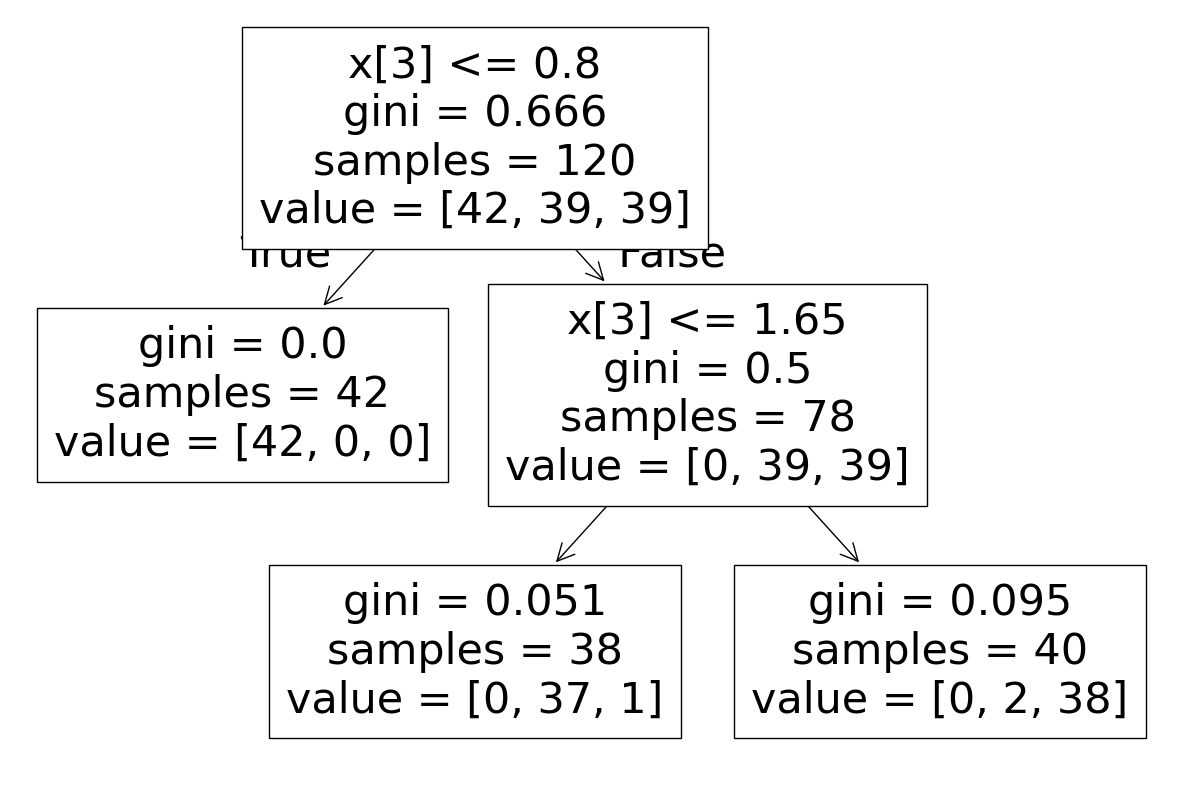

In [17]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dtc)
plt.show()

In [18]:
from sklearn.metrics import accuracy_score,confusion_matrix
ypred=dtc.predict(xtest)
print(confusion_matrix(ytest,ypred))
print(accuracy_score(ytest,ypred))

[[ 8  0  0]
 [ 0 11  0]
 [ 0  3  8]]
0.9


In [ ]:
#Decision tree classifier and Prepruning and Hyperparameter tunning

In [19]:
params = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [1, 2, 3, 4, 5],
    'max_features': ['auto', 'sqrt', 'log2']
}
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier


In [20]:
tm=DecisionTreeClassifier()
grid=GridSearchCV(tm,param_grid=params,cv=5,scoring='accuracy')
grid.fit(xtrain,ytrain)

c:\Desktop\ds\venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
150 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Desktop\ds\venv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Desktop\ds\venv\lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Desktop\ds\venv\lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "c:\Desktop\ds\venv\lib\site-packages\sklearn\utils\_param_valida

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [21]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 3,
 'max_features': 'log2',
 'splitter': 'best'}

In [22]:
grid.best_score_

np.float64(0.975)

In [24]:
ypred2=grid.predict(xtest)
print(confusion_matrix(ytest,ypred))
print(accuracy_score(ytest,ypred))

[[ 8  0  0]
 [ 0 11  0]
 [ 0  3  8]]
0.9


In [25]:
from sklearn.datasets import load_diabetes
data=load_diabetes()

In [27]:
df = pd.DataFrame(data.data, columns=["age", "sex", "BMI", "BP", "S1", "S2", "S3", "S4", "S5", "S6"])
df.head()

,age,sex,BMI,BP,S1,S2,S3,S4,S5,S6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [28]:
x=df
y=data['target']

In [29]:
xt1,xt2,yt1,yt2=train_test_split(x,y,test_size=0.25,random_state=42)

In [30]:
from sklearn.tree import DecisionTreeRegressor
reg=DecisionTreeRegressor()
reg.fit(xt1,yt1)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [31]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'splitter': ['best', 'random'],
    'max_depth': [1, 2, 3, 4, 5, 6, 10, 15, 20, 25],
    'max_features': ['auto', 'sqrt', 'log2']
}
grid = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(xt1,yt1)

c:\Desktop\ds\venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
400 fits failed out of a total of 1200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
400 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Desktop\ds\venv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Desktop\ds\venv\lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Desktop\ds\venv\lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "c:\Desktop\ds\venv\lib\site-packages\sklearn\utils\_param_valid

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'friedman_mse'


In [32]:
grid.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 3,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [37]:
m1=DecisionTreeRegressor(criterion='friedman_mse',max_depth=3,max_features='sqrt',splitter='best')
m1.fit(xt1,yt1)
ypred=m1.predict(xt2)

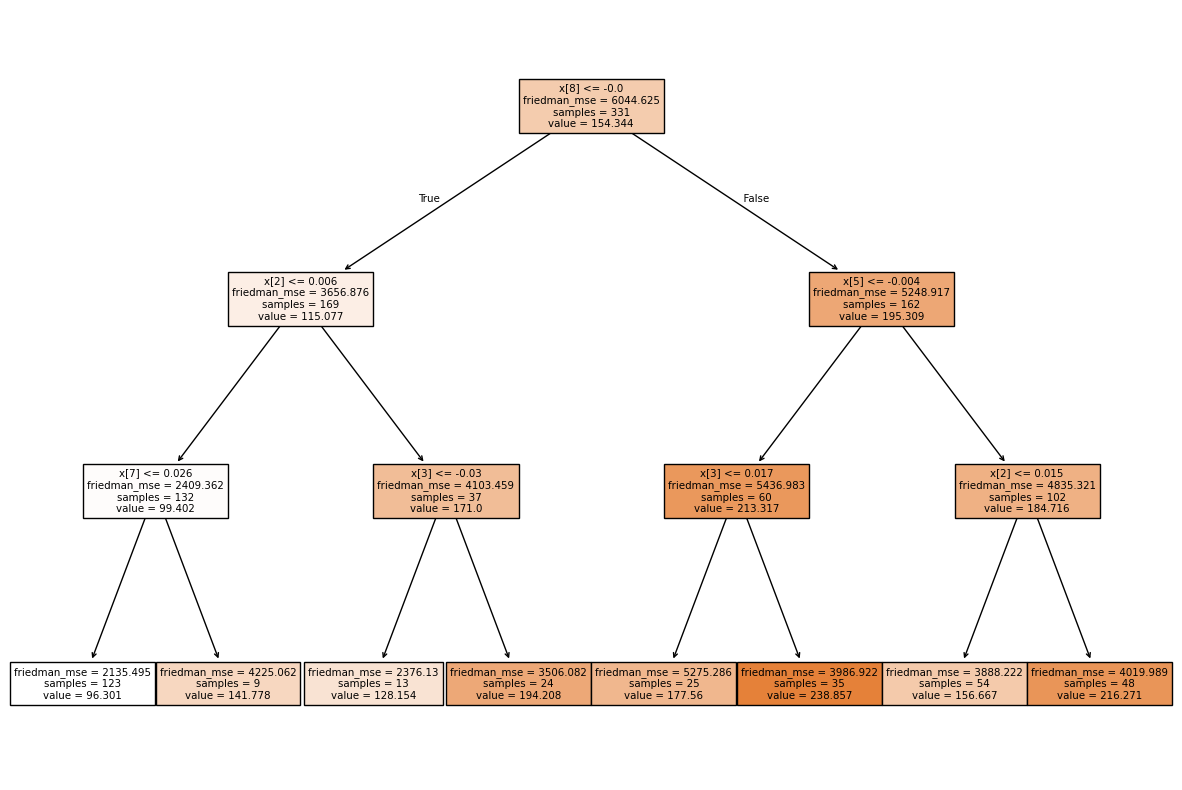

In [38]:
plt.figure(figsize=(15,10))
tree.plot_tree(m1,filled=True)
plt.show()